In [ ]:
%matplotlib widget

import struct
import cdflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_hk_data(csv_file):
    jmag_hk = pd.read_csv(csv_file)
    jmag_hk.columns = [
        "date",
        "FIB_Bx_low",
        "FIB_By_low",
        "FIB_Bz_low",
        "FOB_Bx_low",
        "FOB_By_low",
        "FOB_Bz_low",
        "FIB_Bx_full",
        "FIB_By_full",
        "FIB_Bz_full",
        "FOB_Bx_full",
        "FOB_By_full",
        "FOB_Bz_full"
    ]

    # Convert the 'date' column to datetime
    jmag_hk['date'] = pd.to_datetime(jmag_hk['date'])

    # Plot all 12 data channels
    fig, axes = plt.subplots(4, 3, figsize=(30, 20))
    channels = jmag_hk.columns[1:]  # Exclude the 'date' column

    for i, ax in enumerate(axes.flatten()):
        ax.scatter(jmag_hk['date'], jmag_hk[channels[i]], label=channels[i], s=1)
        #ax.plot(jmag_hk['date'], jmag_hk[channels[i]], label=channels[i])
        ax.set_title(channels[i])
        ax.set_ylabel('Magnetic Field')
        ax.set_xlabel('Date')
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()

    return

def get_multiplicative_factors(hk_path, echoed_Bx , echoed_By, echoed_Bz, echoed_epoch):

    jmag_hk = pd.read_csv(hk_path)
    jmag_hk.columns = [
        "date",
        "FIB_Bx_low",
        "FIB_By_low",
        "FIB_Bz_low",
        "FOB_Bx_low",
        "FOB_By_low",
        "FOB_Bz_low",
        "FIB_Bx_full",
        "FIB_By_full",
        "FIB_Bz_full",
        "FOB_Bx_full",
        "FOB_By_full",
        "FOB_Bz_full"
    ]

    # Convert the 'date' column to datetime
    jmag_hk['date'] = pd.to_datetime(jmag_hk['date'])

    # Initialize lists to store multiplicative factors
    factors_Bx = {"FIB_Bx_low": [], "FOB_Bx_low": [], "FIB_Bx_full": [], "FOB_Bx_full": []}
    factors_By = {"FIB_By_low": [], "FOB_By_low": [], "FIB_By_full": [], "FOB_By_full": []}
    factors_Bz = {"FIB_Bz_low": [], "FOB_Bz_low": [], "FIB_Bz_full": [], "FOB_Bz_full": []}

    # Ensure echoed_epoch is timezone-aware to match jmag_hk['date']
    echoed_epoch = [pd.Timestamp(t).tz_localize('UTC') for t in echoed_epoch]

    # Iterate through each time in echoed_epoch
    for i, time in enumerate(echoed_epoch):
        # Find the closest time in jmag_hk['date']
        closest_idx = (jmag_hk['date'] - time).abs().idxmin()
        
        # Calculate multiplicative factors for Bx
        for key in factors_Bx.keys():
            if not pd.isna(jmag_hk.loc[closest_idx, key]) and jmag_hk.loc[closest_idx, key] != 0:
                factors_Bx[key].append(echoed_Bx[i] / jmag_hk.loc[closest_idx, key])
            else:
                factors_Bx[key].append(np.nan)
        
        # Calculate multiplicative factors for By
        for key in factors_By.keys():
            if not pd.isna(jmag_hk.loc[closest_idx, key]) and jmag_hk.loc[closest_idx, key] != 0:
                factors_By[key].append(echoed_By[i] / jmag_hk.loc[closest_idx, key])
            else:
                factors_By[key].append(np.nan)
        
        # Calculate multiplicative factors for Bz
        for key in factors_Bz.keys():
            if not pd.isna(jmag_hk.loc[closest_idx, key]) and jmag_hk.loc[closest_idx, key] != 0:
                factors_Bz[key].append(echoed_Bz[i] / jmag_hk.loc[closest_idx, key])
            else:
                factors_Bz[key].append(np.nan)

    # Calculate and print the average for each list of multiplicative factors
    for key, values in factors_Bx.items():
        avg = np.nanmean(values)
        print(f"Average multiplicative factor for {key}: {avg}")

    for key, values in factors_By.items():
        avg = np.nanmean(values)
        print(f"Average multiplicative factor for {key}: {avg}")

    for key, values in factors_Bz.items():
        avg = np.nanmean(values)
        print(f"Average multiplicative factor for {key}: {avg}")

    return factors_Bx, factors_By, factors_Bz

def get_magnitudes(hk_path, echoed_Bx, echoed_By, echoed_Bz, echoed_epoch):
    
    jmag_hk = pd.read_csv(hk_path)
    jmag_hk.columns = [
        "date",
        "FIB_Bx_low",
        "FIB_By_low",
        "FIB_Bz_low",
        "FOB_Bx_low",
        "FOB_By_low",
        "FOB_Bz_low",
        "FIB_Bx_full",
        "FIB_By_full",
        "FIB_Bz_full",
        "FOB_Bx_full",
        "FOB_By_full",
        "FOB_Bz_full"
    ]

    # Convert the 'date' column to datetime
    jmag_hk['date'] = pd.to_datetime(jmag_hk['date'])

    B_echoed_list = []
    B_IBS_list = []
    B_OBS_list = []

    # Ensure echoed_epoch is timezone-aware to match jmag_hk['date']
    echoed_epoch = [pd.Timestamp(t).tz_localize('UTC') for t in echoed_epoch]

    fib_Bx = jmag_hk['FIB_Bx_full'].values
    fib_By = jmag_hk['FIB_By_full'].values
    fib_Bz = jmag_hk['FIB_Bz_full'].values
    fob_Bx = jmag_hk['FOB_Bx_full'].values
    fob_By = jmag_hk['FOB_By_full'].values
    fob_Bz = jmag_hk['FOB_Bz_full'].values

    # Get the indices of non-NaN values in the FIB and FOB columns
    fib_indices = np.where(~np.isnan(fib_Bx) & ~np.isnan(fib_By) & ~np.isnan(fib_Bz))
    fob_indices = np.where(~np.isnan(fob_Bx) & ~np.isnan(fob_By) & ~np.isnan(fob_Bz))

    fib_Bx = fib_Bx[fib_indices]
    fib_By = fib_By[fib_indices]
    fib_Bz = fib_Bz[fib_indices]
    fob_Bx = fob_Bx[fob_indices]
    fob_By = fob_By[fob_indices]
    fob_Bz = fob_Bz[fob_indices]

    # Get corresponding time values for non-NaN indices
    fib_times = jmag_hk['date'].iloc[fib_indices].values
    fob_times = jmag_hk['date'].iloc[fob_indices].values

    # Iterate through each time in echoed_epoch
    for i, time in enumerate(echoed_epoch):
        time64 = np.datetime64(time, 'ms')
        closest_idx_fib = np.argmin(np.abs(fib_times - time64))
        closest_idx_fob = np.argmin(np.abs(fob_times - time64))
        B_echoed = np.sqrt(echoed_Bx[i]**2 + echoed_By[i]**2 + echoed_Bz[i]**2)
        B_IBS = np.sqrt(fib_Bx[closest_idx_fib]**2 + fib_By[closest_idx_fib]**2 + fib_Bz[closest_idx_fib]**2)
        B_OBS = np.sqrt(fob_Bx[closest_idx_fob]**2 + fob_By[closest_idx_fob]**2 + fob_Bz[closest_idx_fob]**2)
        B_echoed_list.append(B_echoed)
        B_IBS_list.append(B_IBS)
        B_OBS_list.append(B_OBS)

    return B_echoed_list, B_IBS_list, B_OBS_list

def convert_binstr_to_double_precision(bin_str_array):
    doubles = []
    for bin_str in bin_str_array:
        # Convert binary string to 8-byte integer
        try :
            int_val = int(bin_str, 2)
            bytes_val = int_val.to_bytes(8, byteorder='big')
            double_val = struct.unpack('>d', bytes_val)[0]
            doubles.append(double_val)
        except ValueError as e:
            doubles.append(np.nan)
    return np.array(doubles)

def extract_double_from_columns(data, col_start, col_end):
    # Slice relevant columns: shape (len_JMAG, 8)
    bytes_slice = data[:, col_start:col_end]
    # Transpose and flatten to match MATLAB logic
    bin_strs = [''.join(f'{byte:08b}' for byte in row) for row in bytes_slice]
    return convert_binstr_to_double_precision(bin_strs)

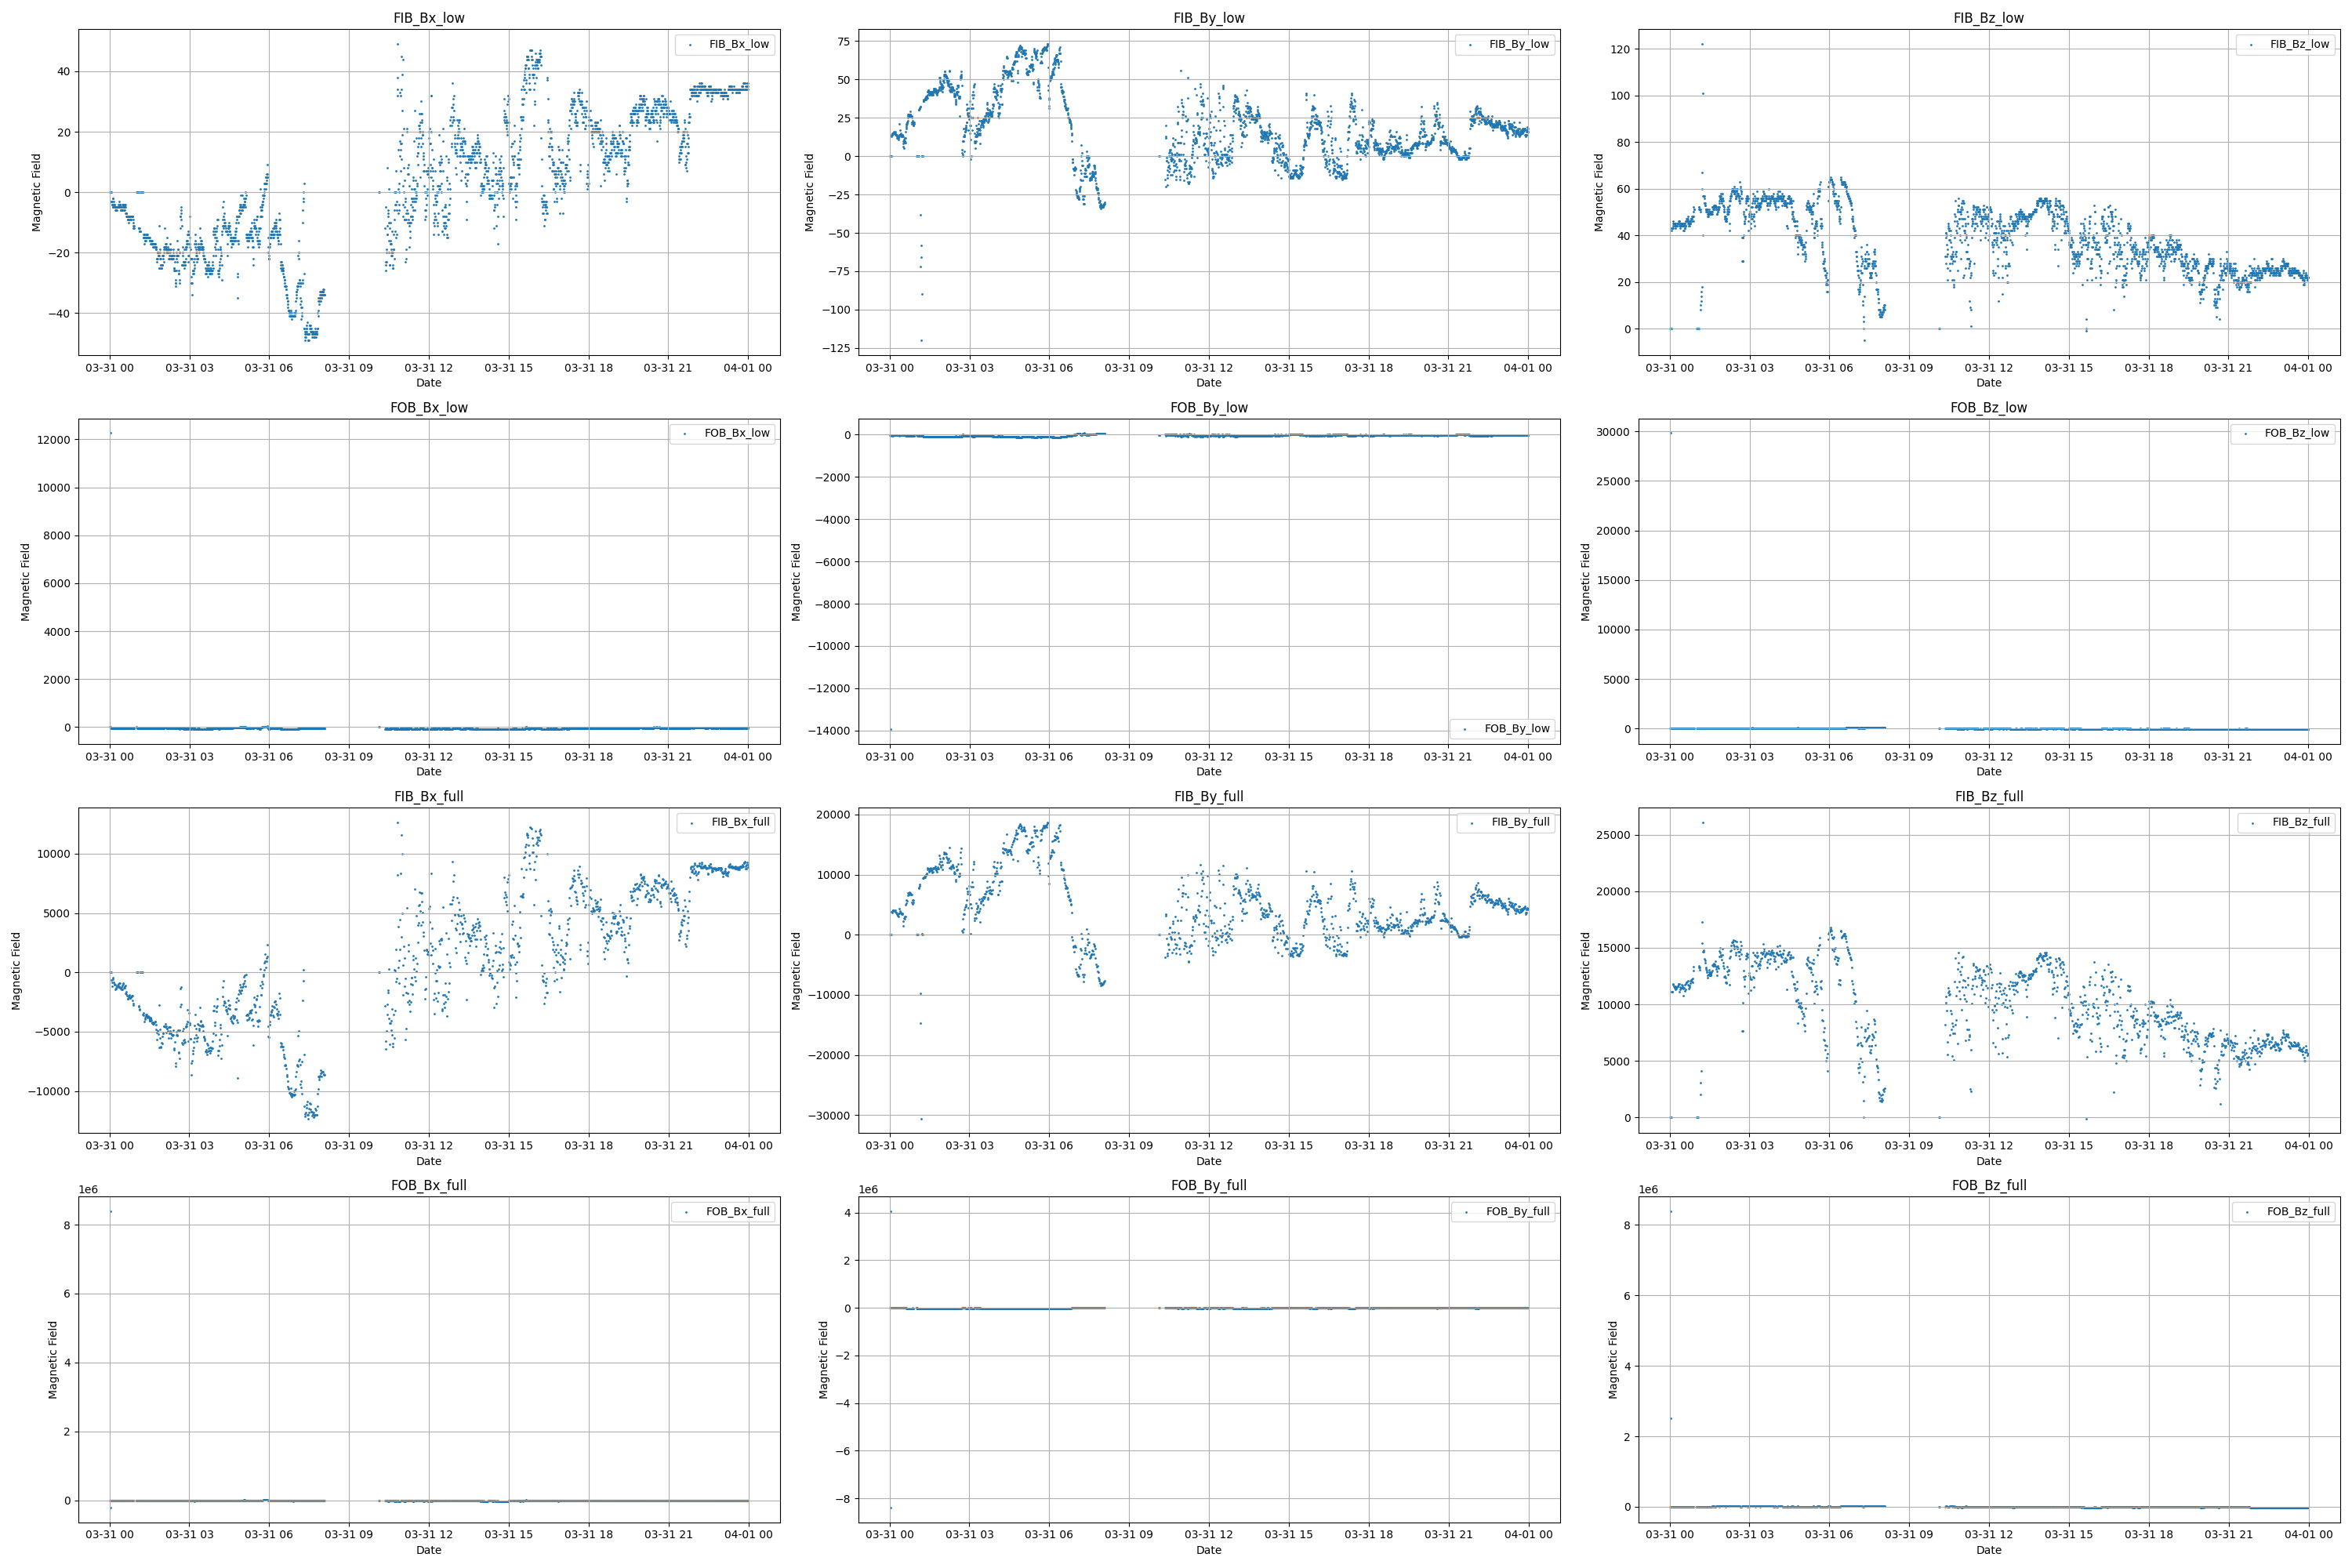

In [8]:
# Reading jmag HK data from 2025/03

csv_file = "../DATA/jmag_extracted_hk/JUI_JMAG_2025-03-01_2025-04-01_V001.csv"

plot_hk_data(csv_file)

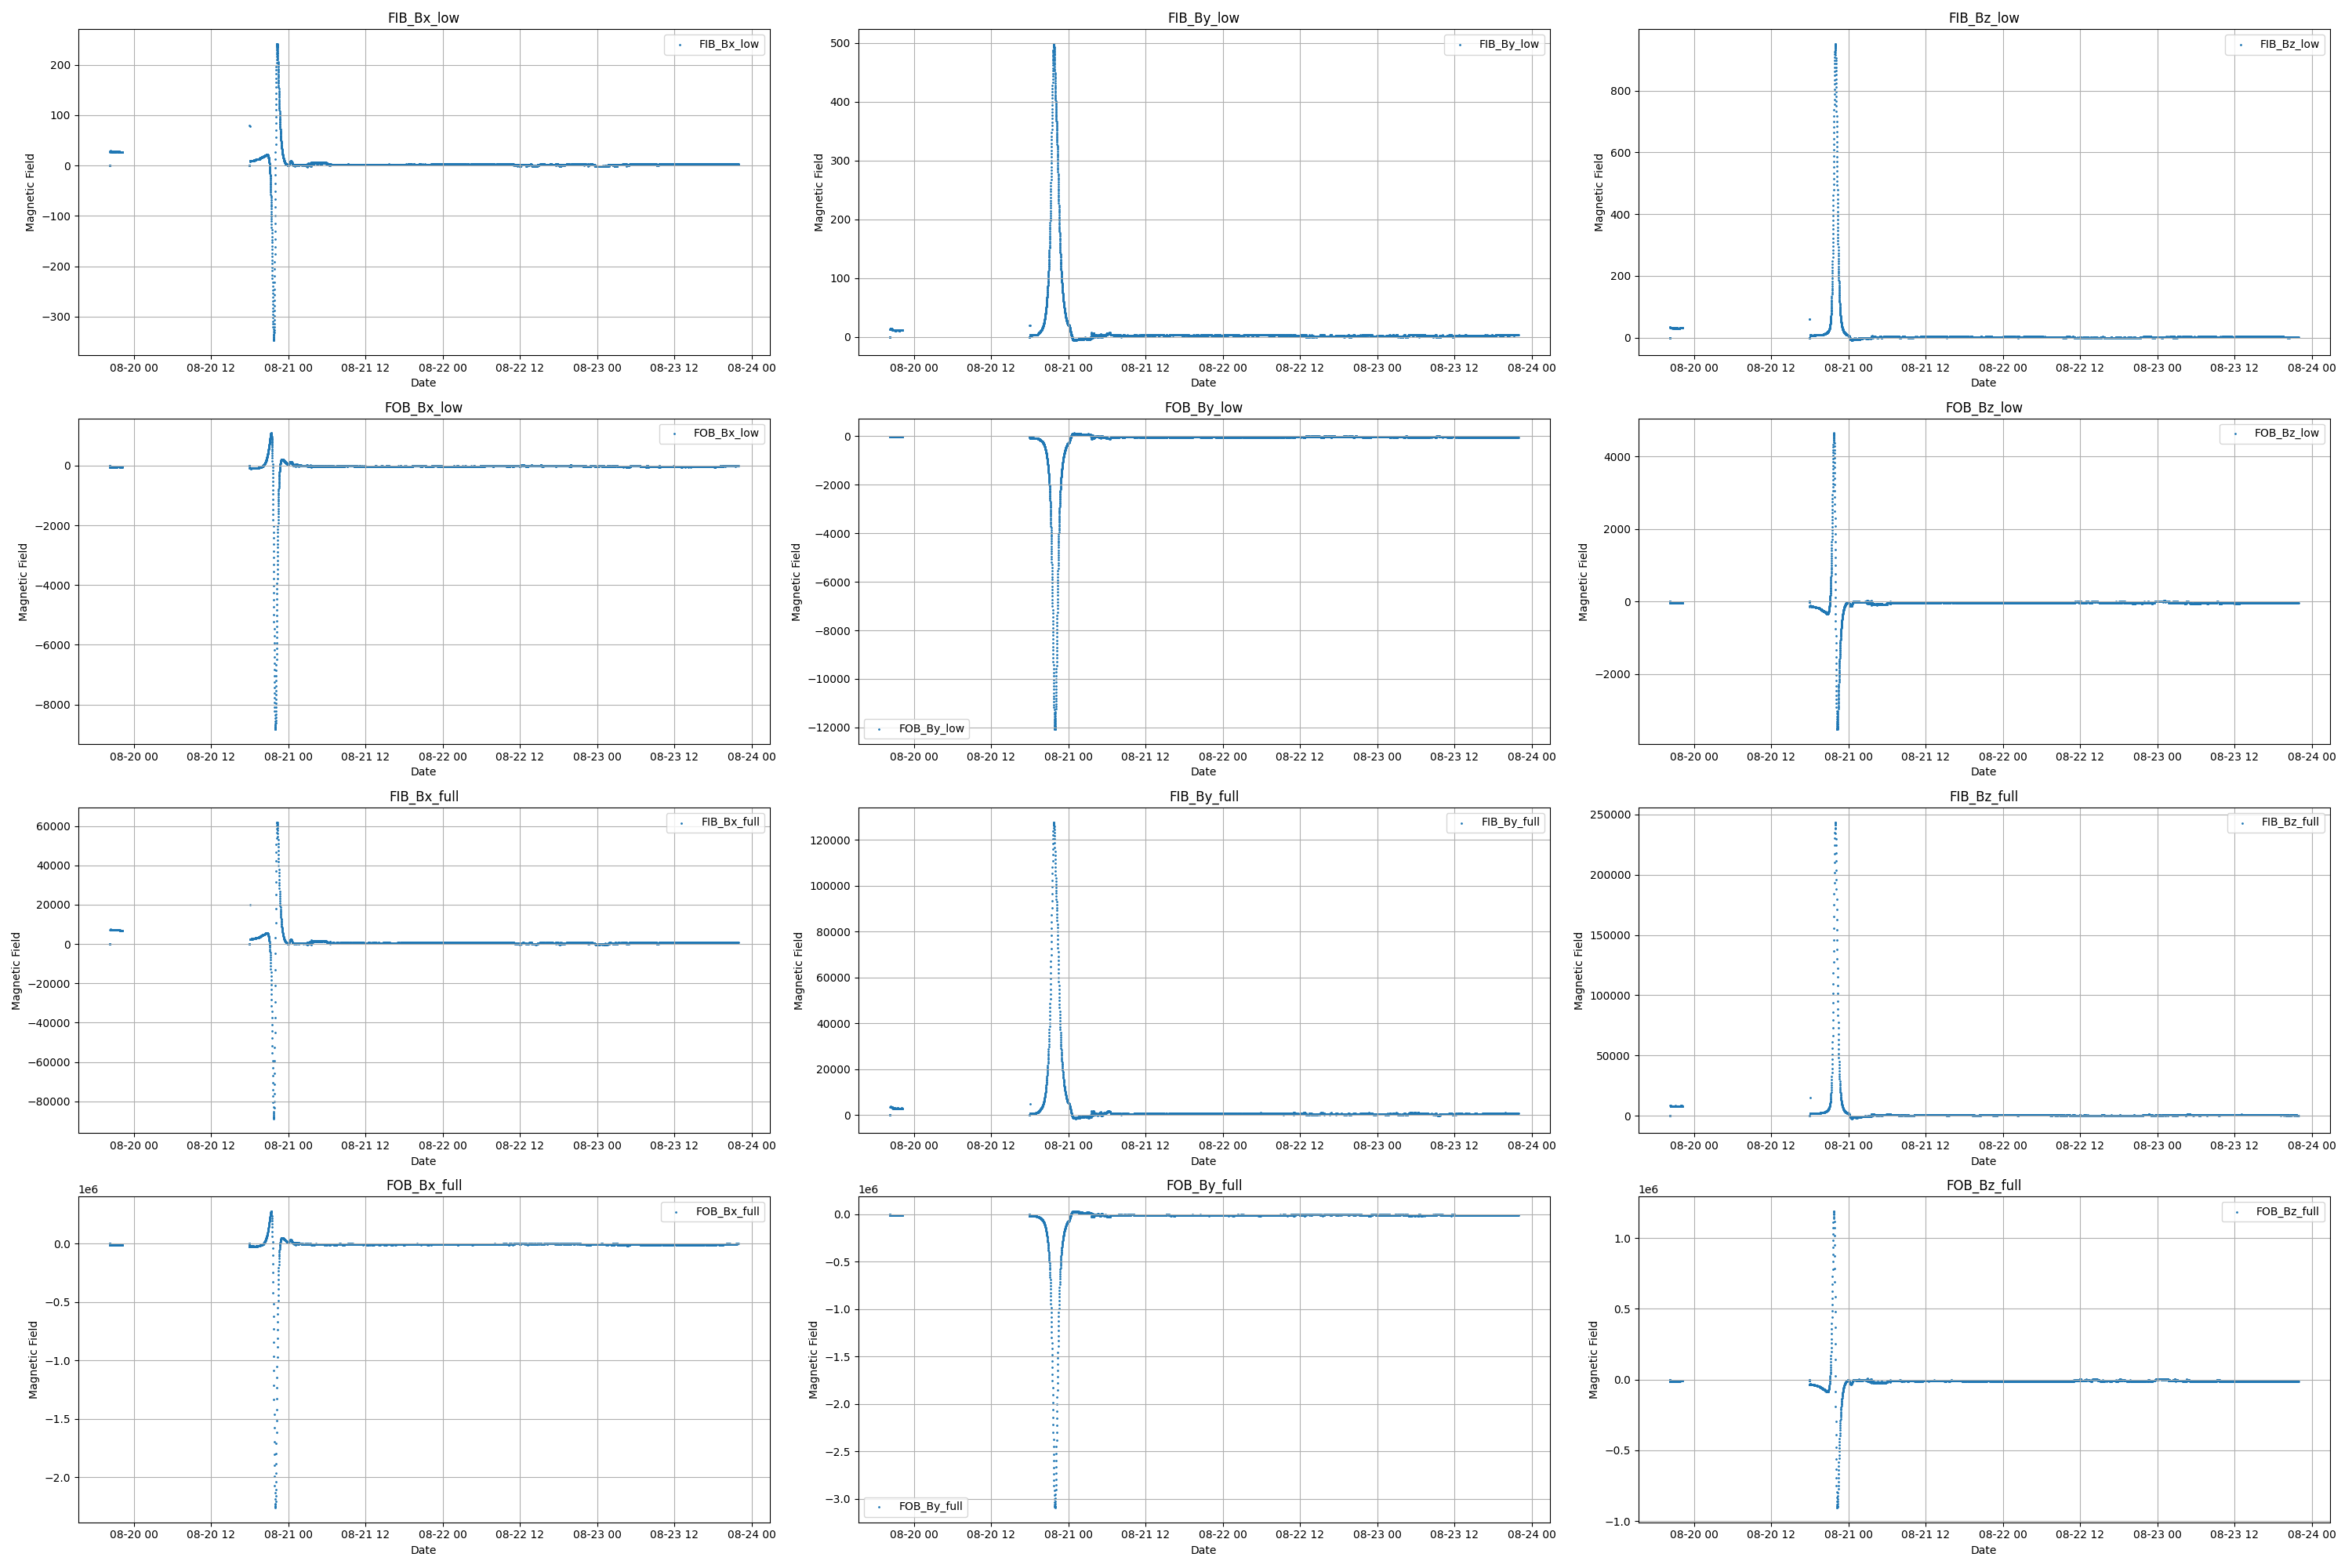

In [9]:
# Reading jmag HK from 2024/08

csv_file = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-08-01_2024-09-01_V001.csv"

plot_hk_data(csv_file)

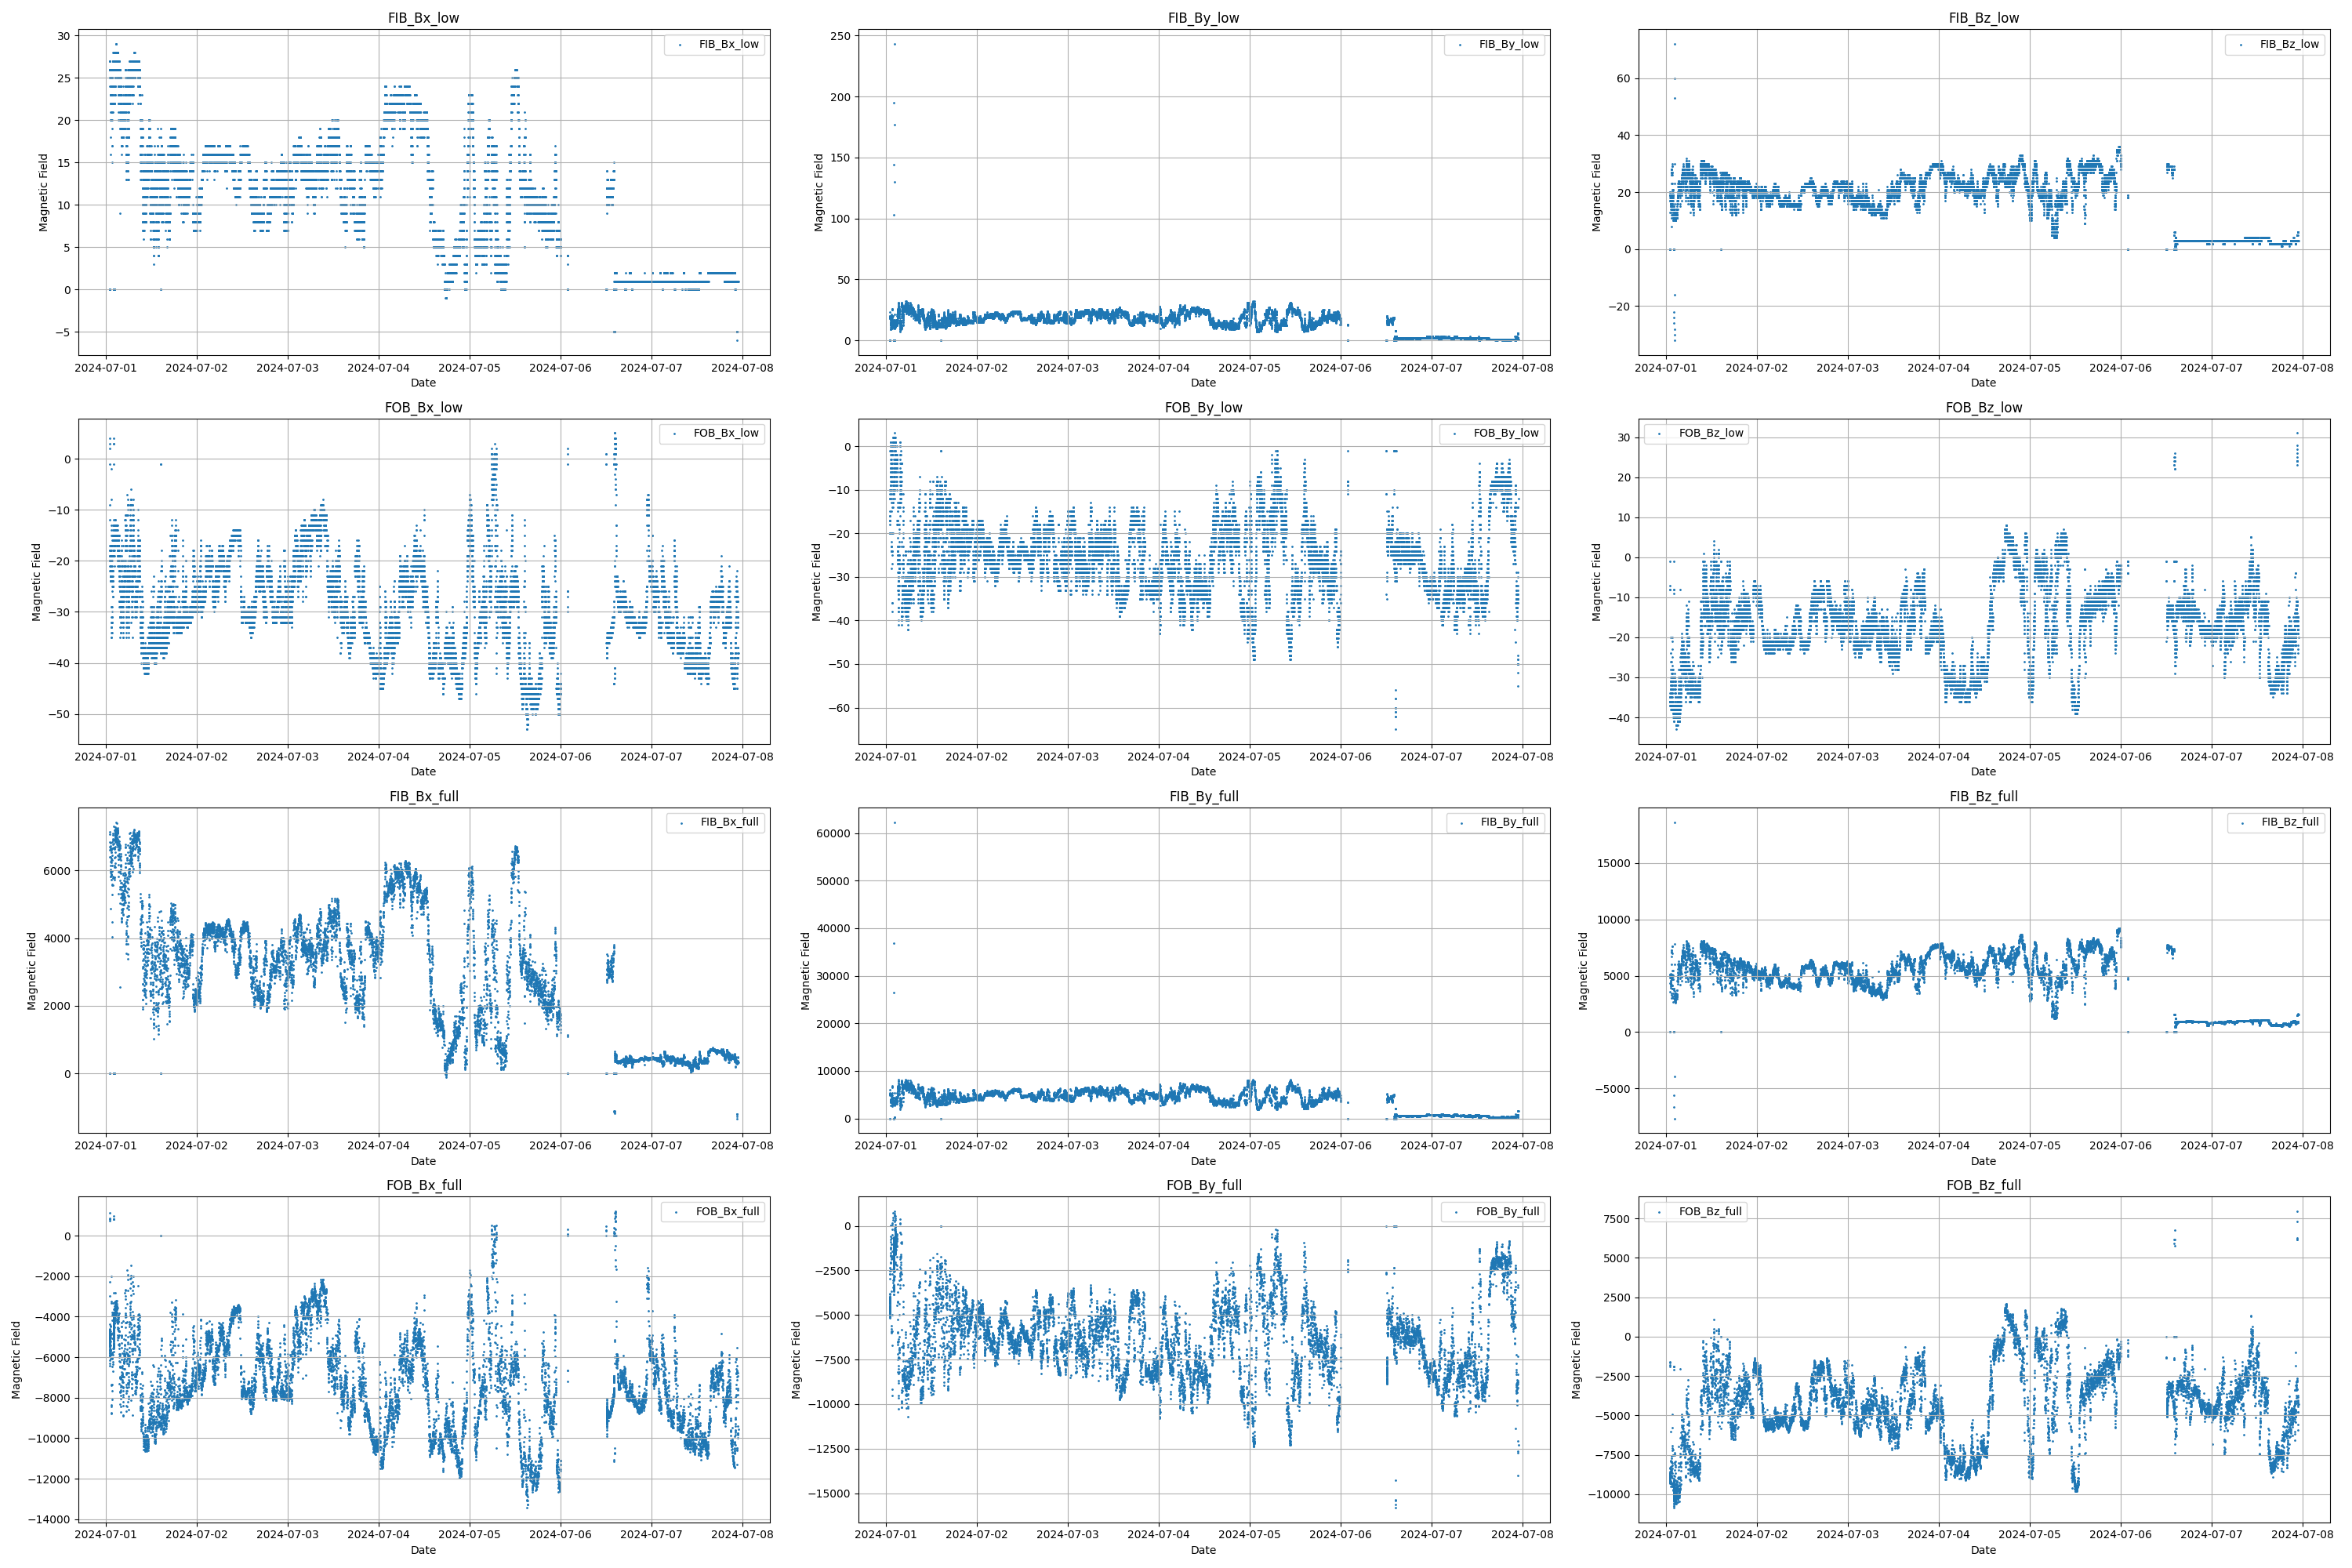

In [10]:
# Reading jmag HK data from 2024/07

csv_file = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-07-01_2024-08-01_V001.csv"

plot_hk_data(csv_file)

In [14]:
# Get multiplicative factors for jmag HK data on 2025/03/31

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2025-03-01_2025-04-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2025/03/31/JUICE_LU_RPWI-PPTD-LWYRPW79710_20250331T030003_V01.cdf"

echoed_cdf = cdflib.CDF(echoed_path)

echoed_epoch = echoed_cdf.varget('Epoch')
echoed_Bx = echoed_cdf.varget('LWT79713')
echoed_By = echoed_cdf.varget('LWT79714')
echoed_Bz = echoed_cdf.varget('LWT79715')

echoed_epoch = cdflib.cdfepoch.to_datetime(echoed_epoch)
echoed_epoch = np.array(echoed_epoch, dtype='datetime64[ms]').astype('O')

# Rotation matrix to go from JMAG frame to JUICE frame
R = np.array([
    [-7.77145961*1e-1,  8.39299198*1e-17,   -6.29320391*1e-1],
    [-9.51729314*1e-17, -1.00000000*1e0,    -1.58371803*1e-17],
    [-6.29320391*1e-1,  4.75864657*1e-17,   7.77145961*1e-1]])

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R[0,0]*echoed_Bx + R[0,1]*echoed_By + R[0,2]*echoed_Bz
By_rot = R[1,0]*echoed_Bx + R[1,1]*echoed_By + R[1,2]*echoed_Bz
Bz_rot = R[2,0]*echoed_Bx + R[2,1]*echoed_By + R[2,2]*echoed_Bz
echoed_Bx = Bx_rot
echoed_By = By_rot
echoed_Bz = Bz_rot

factors_Bx, factors_By, factors_Bz = get_multiplicative_factors(hk_path, echoed_Bx, echoed_By, echoed_Bz, echoed_epoch)

Average multiplicative factor for FIB_Bx_low: 0.11915210133051606
Average multiplicative factor for FOB_Bx_low: 0.07486765779089008
Average multiplicative factor for FIB_Bx_full: 0.0005000728035185565
Average multiplicative factor for FOB_Bx_full: 0.00032680722707069176
Average multiplicative factor for FIB_By_low: 0.2702501573598344
Average multiplicative factor for FOB_By_low: -0.09894987329513144
Average multiplicative factor for FIB_By_full: -0.00033528538859235225
Average multiplicative factor for FOB_By_full: -0.00041381741776189016
Average multiplicative factor for FIB_Bz_low: 0.42566939464323855
Average multiplicative factor for FOB_Bz_low: 0.46145839535278427
Average multiplicative factor for FIB_Bz_full: 0.0016691934829535192
Average multiplicative factor for FOB_Bz_full: 0.0017242333602090793


In [15]:
# Get multiplicative factors for jmag HK data on 2024/08/21

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-08-01_2024-09-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2024/08/21/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240821T042902_V01.cdf"

echoed_cdf = cdflib.CDF(echoed_path)

NMD = echoed_cdf.varget('NMD')
epoch = echoed_cdf.varget('Epoch')
epoch = cdflib.cdfepoch.to_datetime(epoch)
epoch = np.array(epoch, dtype='datetime64[ms]').astype('O')

echoed_Bx = extract_double_from_columns(NMD, 9, 17)
echoed_By = extract_double_from_columns(NMD, 17, 25)
echoed_Bz = extract_double_from_columns(NMD, 25, 33)

echoed_Bx = np.where(np.abs(echoed_Bx) < 1e-9, np.nan, echoed_Bx)
echoed_By = np.where(np.abs(echoed_By) < 1e-9, np.nan, echoed_By)
echoed_Bz = np.where(np.abs(echoed_Bz) < 1e-9, np.nan, echoed_Bz)

# Rotation matrix to go from JMAG frame to JUICE frame
R = np.array([
    [-7.77145961*1e-1,  8.39299198*1e-17,   -6.29320391*1e-1],
    [-9.51729314*1e-17, -1.00000000*1e0,    -1.58371803*1e-17],
    [-6.29320391*1e-1,  4.75864657*1e-17,   7.77145961*1e-1]])

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R[0,0]*echoed_Bx + R[0,1]*echoed_By + R[0,2]*echoed_Bz
By_rot = R[1,0]*echoed_Bx + R[1,1]*echoed_By + R[1,2]*echoed_Bz
Bz_rot = R[2,0]*echoed_Bx + R[2,1]*echoed_By + R[2,2]*echoed_Bz
echoed_Bx = Bx_rot
echoed_By = By_rot
echoed_Bz = Bz_rot

factors_Bx, factors_By, factors_Bz = get_multiplicative_factors(hk_path, echoed_Bx, echoed_By, echoed_Bz, epoch)

Average multiplicative factor for FIB_Bx_low: -2.551808809053778
Average multiplicative factor for FOB_Bx_low: 0.29117261702160924
Average multiplicative factor for FIB_Bx_full: -0.007019541223978029
Average multiplicative factor for FOB_Bx_full: 0.0010994683246805532
Average multiplicative factor for FIB_By_low: -0.9020527710239783
Average multiplicative factor for FOB_By_low: 0.12262199945389742
Average multiplicative factor for FIB_By_full: -0.030732168473434143
Average multiplicative factor for FOB_By_full: 0.0003581061065540736
Average multiplicative factor for FIB_Bz_low: -2.403051261964226
Average multiplicative factor for FOB_Bz_low: -0.04039214540646161
Average multiplicative factor for FIB_Bz_full: -0.011320902546657786
Average multiplicative factor for FOB_Bz_full: -0.0001674387042444634


In [16]:
# Get multiplicative factors for jmag HK data on 2024/07/02

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-07-01_2024-08-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2024/07/02/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240702T003500_V02.cdf"

echoed_cdf = cdflib.CDF(echoed_path)

NMD = echoed_cdf.varget('NMD')
epoch = echoed_cdf.varget('Epoch')
epoch = cdflib.cdfepoch.to_datetime(epoch)
epoch = np.array(epoch, dtype='datetime64[ms]').astype('O')

echoed_Bx = extract_double_from_columns(NMD, 9, 17)
echoed_By = extract_double_from_columns(NMD, 17, 25)
echoed_Bz = extract_double_from_columns(NMD, 25, 33)

echoed_Bx = np.where(np.abs(echoed_Bx) < 1e-9, np.nan, echoed_Bx)
echoed_By = np.where(np.abs(echoed_By) < 1e-9, np.nan, echoed_By)
echoed_Bz = np.where(np.abs(echoed_Bz) < 1e-9, np.nan, echoed_Bz)

# Rotation matrix to go from JMAG frame to JUICE frame
R = np.array([
    [-7.77145961*1e-1,  8.39299198*1e-17,   -6.29320391*1e-1],
    [-9.51729314*1e-17, -1.00000000*1e0,    -1.58371803*1e-17],
    [-6.29320391*1e-1,  4.75864657*1e-17,   7.77145961*1e-1]])

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R[0,0]*echoed_Bx + R[0,1]*echoed_By + R[0,2]*echoed_Bz
By_rot = R[1,0]*echoed_Bx + R[1,1]*echoed_By + R[1,2]*echoed_Bz
Bz_rot = R[2,0]*echoed_Bx + R[2,1]*echoed_By + R[2,2]*echoed_Bz
echoed_Bx = Bx_rot
echoed_By = By_rot
echoed_Bz = Bz_rot

factors_Bx, factors_By, factors_Bz = get_multiplicative_factors(hk_path, echoed_Bx, echoed_By, echoed_Bz, epoch)

Average multiplicative factor for FIB_Bx_low: -2.1081054382721622
Average multiplicative factor for FOB_Bx_low: 0.7951549687070602
Average multiplicative factor for FIB_Bx_full: -0.007871279004004163
Average multiplicative factor for FOB_Bx_full: 0.0031812842146620303
Average multiplicative factor for FIB_By_low: -1.1175310193984613
Average multiplicative factor for FOB_By_low: 0.930622146207757
Average multiplicative factor for FIB_By_full: -0.004219850295741145
Average multiplicative factor for FOB_By_full: 0.00376365543936719
Average multiplicative factor for FIB_Bz_low: 0.37260847249174267
Average multiplicative factor for FOB_Bz_low: -0.6243218992128201
Average multiplicative factor for FIB_Bz_full: 0.0014454742665844789
Average multiplicative factor for FOB_Bz_full: -0.0026143532338522026


C:\Users\lesco\AppData\Local\Temp\ipykernel_22172\4135028774.py:173: UserWarning: no explicit representation of timezones available for np.datetime64
  time64 = np.datetime64(time, 'ms')


IBS factor: 0.0015067717622824156
OBS factor: 0.0009689390858173584


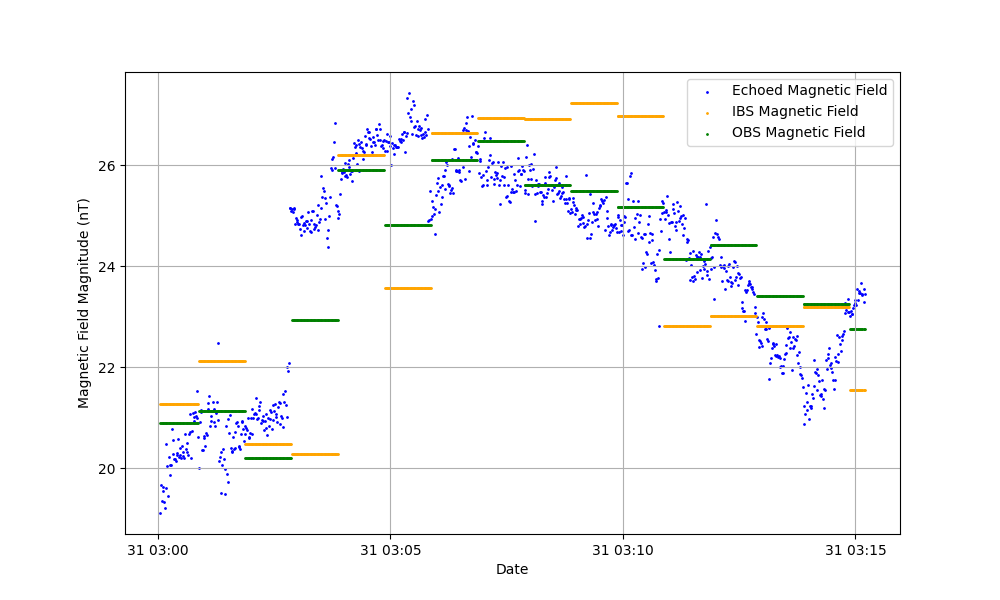

In [2]:
# Get |B| multiplicative factors for 2025/03/31

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2025-03-01_2025-04-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2025/03/31/JUICE_LU_RPWI-PPTD-LWYRPW79710_20250331T030003_V01.cdf"

echoed_cdf = cdflib.CDF(echoed_path)

echoed_epoch = echoed_cdf.varget('Epoch')
echoed_Bx = echoed_cdf.varget('LWT79713')
echoed_By = echoed_cdf.varget('LWT79714')
echoed_Bz = echoed_cdf.varget('LWT79715')

echoed_epoch = cdflib.cdfepoch.to_datetime(echoed_epoch)
echoed_epoch = np.array(echoed_epoch, dtype='datetime64[ms]').astype('O')

B_echoed, B_IBS, B_OBS = get_magnitudes(hk_path, echoed_Bx, echoed_By, echoed_Bz, echoed_epoch)

IBS_factor = np.nanmean(B_echoed) / np.nanmean(B_IBS)
OBS_factor = np.nanmean(B_echoed) / np.nanmean(B_OBS)

print(f"IBS factor: {IBS_factor}")
print(f"OBS factor: {OBS_factor}")

plt.figure(figsize=(10, 6))
plt.scatter(echoed_epoch, B_echoed, label='Echoed Magnetic Field', s=1, color='blue')
plt.scatter(echoed_epoch, IBS_factor*np.array(B_IBS), label='IBS Magnetic Field', s=1, color='orange')
plt.scatter(echoed_epoch, OBS_factor*np.array(B_OBS), label='OBS Magnetic Field', s=1, color='green')
plt.xlabel('Date')
plt.ylabel('Magnetic Field Magnitude (nT)')
plt.grid()
plt.legend()
plt.show()

C:\Users\lesco\AppData\Local\Temp\ipykernel_25128\4135028774.py:173: UserWarning: no explicit representation of timezones available for np.datetime64
  time64 = np.datetime64(time, 'ms')
C:\Users\lesco\AppData\Local\Temp\ipykernel_25128\4135028774.py:173: UserWarning: no explicit representation of timezones available for np.datetime64
  time64 = np.datetime64(time, 'ms')


IBS factor for first part: 0.011272037555522373
OBS factor for first part: 0.0008485777373500684


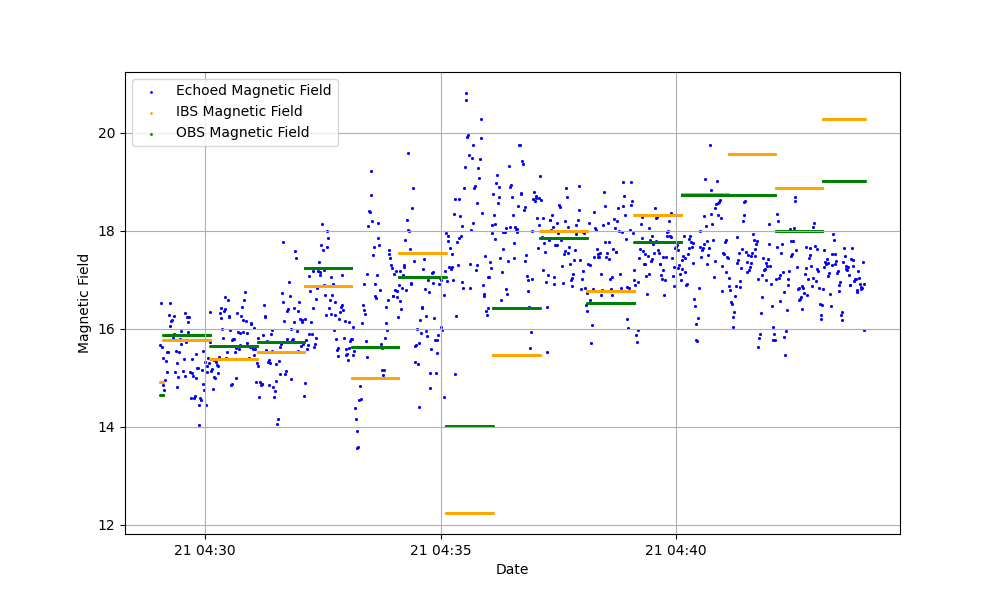

IBS factor for second part: 0.004623481376139291
OBS factor for second part: 0.0004157668674028542


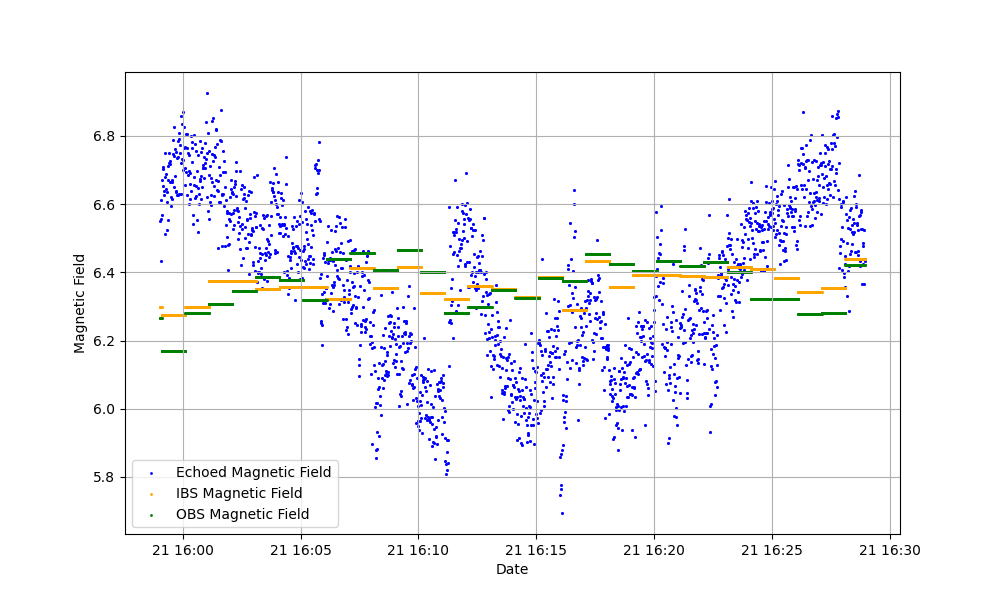

In [3]:
# Get |B| multiplicative factors for 2024/08/21

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-08-01_2024-09-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2024/08/21/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240821T042902_V01.cdf"

echoed_cdf = cdflib.CDF(echoed_path)
echoed_epoch = echoed_cdf.varget('Epoch')
NMD = echoed_cdf.varget('NMD')
echoed_epoch = cdflib.cdfepoch.to_datetime(echoed_epoch)
echoed_epoch = np.array(echoed_epoch, dtype='datetime64[ms]').astype('O')
echoed_Bx = extract_double_from_columns(NMD, 9, 17)
echoed_By = extract_double_from_columns(NMD, 17, 25)
echoed_Bz = extract_double_from_columns(NMD, 25, 33)

echoed_Bx = np.where(np.abs(echoed_Bx) < 1e-9, np.nan, echoed_Bx)
echoed_By = np.where(np.abs(echoed_By) < 1e-9, np.nan, echoed_By)
echoed_Bz = np.where(np.abs(echoed_Bz) < 1e-9, np.nan, echoed_Bz)

packet1 = echoed_epoch < np.datetime64('2024-08-21T12:00:00')

echoed_epoch1 = echoed_epoch[packet1]
echoed_Bx1 = echoed_Bx[packet1]
echoed_By1 = echoed_By[packet1]
echoed_Bz1 = echoed_Bz[packet1]

echoed_epoch2 = echoed_epoch[~packet1]
echoed_Bx2 = echoed_Bx[~packet1]
echoed_By2 = echoed_By[~packet1]
echoed_Bz2 = echoed_Bz[~packet1]

B_echoed1, B_IBS1, B_OBS1 = get_magnitudes(hk_path, echoed_Bx1, echoed_By1, echoed_Bz1, echoed_epoch1)

B_echoed2, B_IBS2, B_OBS2 = get_magnitudes(hk_path, echoed_Bx2, echoed_By2, echoed_Bz2, echoed_epoch2)

IBS_factor1 = np.nanmean(B_echoed1) / np.nanmean(B_IBS1)
OBS_factor1 = np.nanmean(B_echoed1) / np.nanmean(B_OBS1)

print(f"IBS factor for first part: {IBS_factor1}")
print(f"OBS factor for first part: {OBS_factor1}")

plt.figure(figsize=(10, 6))
plt.scatter(echoed_epoch1, B_echoed1, label='Echoed Magnetic Field', s=1, color='blue')
plt.scatter(echoed_epoch1, IBS_factor1*np.array(B_IBS1), label='IBS Magnetic Field', s=1, color='orange')
plt.scatter(echoed_epoch1, OBS_factor1*np.array(B_OBS1), label='OBS Magnetic Field', s=1, color='green')
plt.xlabel('Date')
plt.ylabel('Magnetic Field')
plt.legend()
plt.grid()
plt.show()

IBS_factor2 = np.nanmean(B_echoed2) / np.nanmean(B_IBS2)
OBS_factor2 = np.nanmean(B_echoed2) / np.nanmean(B_OBS2)

print(f"IBS factor for second part: {IBS_factor2}")
print(f"OBS factor for second part: {OBS_factor2}")

plt.figure(figsize=(10, 6))
plt.scatter(echoed_epoch2, B_echoed2, label='Echoed Magnetic Field', s=1, color='blue')
plt.scatter(echoed_epoch2, IBS_factor2*np.array(B_IBS2), label='IBS Magnetic Field', s=1, color='orange')
plt.scatter(echoed_epoch2, OBS_factor2*np.array(B_OBS2), label='OBS Magnetic Field', s=1, color='green')
plt.xlabel('Date')
plt.ylabel('Magnetic Field')
plt.legend()
plt.grid()
plt.show()

C:\Users\lesco\AppData\Local\Temp\ipykernel_25128\4135028774.py:173: UserWarning: no explicit representation of timezones available for np.datetime64
  time64 = np.datetime64(time, 'ms')


IBS factor: 0.004071585468117316
OBS factor: 0.003299272701041773


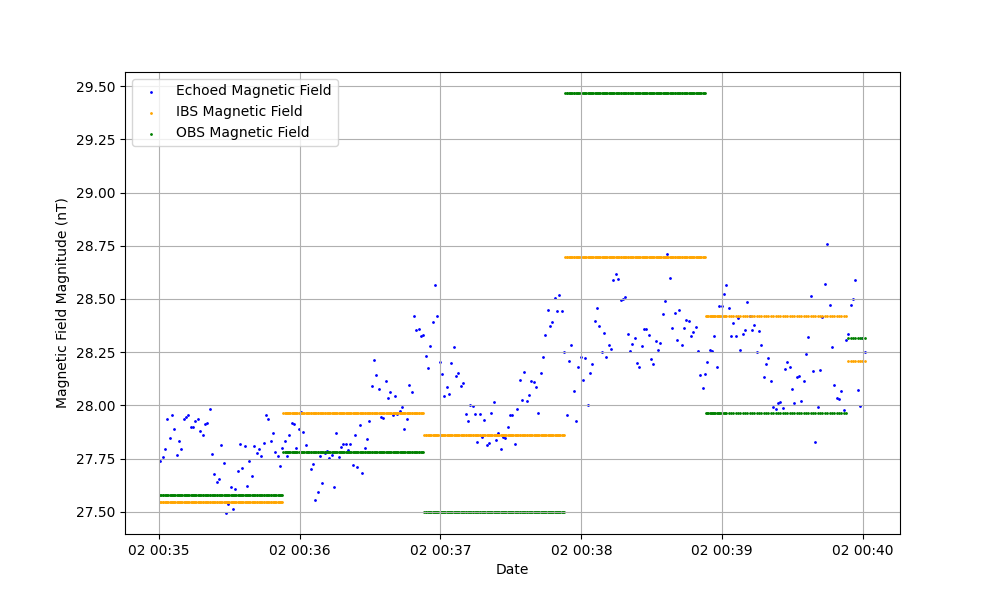

In [2]:
# Get |B| multiplicative factors for 2024/07/02

hk_path = "../DATA/jmag_extracted_hk/JUI_JMAG_2024-07-01_2024-08-01_V001.csv"
echoed_path = "../DATA/jmag_echoed/2024/07/02/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240702T003500_V02.cdf"

echoed_cdf = cdflib.CDF(echoed_path)

NMD = echoed_cdf.varget('NMD')
epoch = echoed_cdf.varget('Epoch')
epoch = cdflib.cdfepoch.to_datetime(epoch)
epoch = np.array(epoch, dtype='datetime64[ms]').astype('O')

echoed_Bx = extract_double_from_columns(NMD, 9, 17)
echoed_By = extract_double_from_columns(NMD, 17, 25)
echoed_Bz = extract_double_from_columns(NMD, 25, 33)

echoed_Bx = np.where(np.abs(echoed_Bx) < 1e-9, np.nan, echoed_Bx)
echoed_By = np.where(np.abs(echoed_By) < 1e-9, np.nan, echoed_By)
echoed_Bz = np.where(np.abs(echoed_Bz) < 1e-9, np.nan, echoed_Bz)

B_echoed, B_IBS, B_OBS = get_magnitudes(hk_path, echoed_Bx, echoed_By, echoed_Bz, epoch)

IBS_factor = np.nanmean(B_echoed) / np.nanmean(B_IBS)
OBS_factor = np.nanmean(B_echoed) / np.nanmean(B_OBS)

print(f"IBS factor: {IBS_factor}")
print(f"OBS factor: {OBS_factor}")

plt.figure(figsize=(10, 6))
plt.scatter(epoch, B_echoed, label='Echoed Magnetic Field', s=1, color='blue')
plt.scatter(epoch, IBS_factor*np.array(B_IBS), label='IBS Magnetic Field', s=1, color='orange')
plt.scatter(epoch, OBS_factor*np.array(B_OBS), label='OBS Magnetic Field', s=1, color='green')
plt.xlabel('Date')
plt.ylabel('Magnetic Field Magnitude (nT)')
plt.grid()
plt.legend()
plt.show()